# HOWP 7-Condition FOL Candidate Selection Experiment

**HOWP (Heterogeneous Oracle World Probing)** is a pipeline for FOL candidate selection that compares 7 conditions across synthetic NLI examples.

**What this artifact does:**
- Generates a synthetic NLI dataset with controlled FOL structure (entailment / contradiction / neutral)
- Uses LLaMA-3.1-70B to generate k=5 FOL formula candidates per example (beam recall gate)
- Uses Qwen-2.5-7B as a heterogeneous oracle to score candidates via world-probing
- Compares 7 selection conditions: `howp_hetero`, `howp_same`, `howp_random`, `howp_m4`, `top1`, `self_consist`, `direct_judge`
- Evaluates each condition's accuracy using Z3-based FOL entailment checking

**This demo** walks through: dataset building → Z3 smoke tests → HOWP scoring logic → analysis of pre-computed results.  
Live LLM calls (OpenRouter) are skipped; pre-computed results are loaded from `mini_demo_data.json`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, editdistance, loguru — NOT pre-installed on Colab
_pip('z3-solver==4.16.0.0')
_pip('editdistance==0.8.1')
_pip('loguru==0.7.3')

# matplotlib, numpy — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0', 'numpy==2.0.2')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import asyncio
import gc
import json
import math
import os
import re
import sys
import time
from pathlib import Path
from typing import Any

import editdistance
from loguru import logger
from z3 import (
    DeclareSort, Function, BoolSort, Const, Solver,
    ForAll, Exists, And, Or, Not, Implies,
    unsat, unknown, sat, BoolVal
)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 5)

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-8ad782-beam-recall-as-the-binding-constraint-an/main/round-2/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("Loaded data keys:", list(data.keys()))
print("Metadata:", json.dumps(data["metadata"], indent=2))

Loaded data keys: ['metadata', 'datasets']
Metadata: {
  "experiment": "howp_iter2_synthetic",
  "dataset": "synthetic_single_multi_premise",
  "generator_model": "meta-llama/llama-3.1-70b-instruct",
  "oracle_model": "qwen/qwen-2.5-7b-instruct",
  "n_examples": 100,
  "beam_recall": {
    "k5": 1.0,
    "passed_gate": true
  },
  "in_distribution_oracle_accuracy": 0.6667,
  "results": {
    "howp_hetero": {
      "accuracy": 0.93,
      "n": 100,
      "correct": 93
    },
    "howp_same": {
      "accuracy": 0.93,
      "n": 100,
      "correct": 93
    },
    "howp_random": {
      "accuracy": 0.96,
      "n": 100,
      "correct": 96
    },
    "howp_m4": {
      "accuracy": 0.93,
      "n": 100,
      "correct": 93
    },
    "top1": {
      "accuracy": 0.94,
      "n": 100,
      "correct": 94
    },
    "self_consist": {
      "accuracy": 0.94,
      "n": 100,
      "correct": 94
    },
    "direct_judge": {
      "accuracy": 0.99,
      "n": 100,
      "correct": 99
    }
  },


## Config

All tunable parameters from the original experiment. Start with minimum values for a fast demo run; scale up to original values for a full experiment (requires OpenRouter API key and ~$0.08 budget).

In [5]:
# ── Demo config (minimum values for fast local run) ──────────────────────────
N_DATASET_TOTAL  = 9       # total synthetic examples to build (min=9 for 3 per label)
                           # original: 175 (50 beam_recall + 100 main + 25 oracle_pilot)
N_BEAM_RECALL    = 3       # examples used for beam recall gate
                           # original: 50
N_MAIN           = 3       # examples used for main HOWP pipeline
                           # original: 100
N_ORACLE_PILOT   = 3       # examples used for oracle validation
                           # original: 25
K_CANDIDATES     = 5       # FOL candidates per example (requires LLM; only used in full run)
                           # original: 5
M_WORLDS         = 8       # diagnostic worlds per example (requires LLM; only used in full run)
                           # original: 8
M_WORLDS_M4      = 4       # worlds for howp_m4 condition
                           # original: 4
BATCH_SIZE       = 3       # parallel batch size for full pipeline
                           # original: 5
BUDGET_USD       = 9.0     # total LLM cost budget in USD (original: 9.0)
BEAM_RECALL_GATE = 0.60    # gate threshold (original: 0.60)
DATASET_SEED     = 42      # random seed for synthetic data generation

## Phase A: Synthetic Dataset Builder

The experiment generates a synthetic NLI dataset with 3 label types and controlled FOL structure. No LLM calls needed — all patterns are rule-based.

- **entailment**: `All X are Y. Name is X. → Name is Y.` (also 2-hop chains)
- **contradiction**: `No X are Y. Name is X. → Name is Y.`
- **neutral**: `Some X are Y. → Name is Y.` (or negation neutral)

Gold FOL is in NLTK syntax, verified by Z3.

In [6]:
CATEGORIES = [
    ("student", "Student"), ("teacher", "Teacher"), ("doctor", "Doctor"),
    ("dog", "Dog"), ("cat", "Cat"), ("bird", "Bird"),
    ("car", "Car"), ("book", "Book"), ("robot", "Robot"), ("plant", "Plant"),
]
PROPERTIES = [
    ("smart", "Smart"), ("fast", "Fast"), ("friendly", "Friendly"),
    ("large", "Large"), ("happy", "Happy"), ("old", "Old"),
    ("rare", "Rare"), ("loud", "Loud"), ("quiet", "Quiet"), ("bright", "Bright"),
]
NAMES = ["Alice", "Bob", "Carol", "Dave", "Eve", "Frank", "Grace", "Henry", "Iris", "Jack"]


def _make_entailment_example(cat_nl, cat_fol, prop_nl, prop_fol, name) -> dict:
    """All X are Y. Name is X. → Name is Y. (entailment)"""
    return {
        "premises_nl": [f"All {cat_nl}s are {prop_nl}.", f"{name} is a {cat_nl}."],
        "premises_fol": [
            f"all x. ({cat_fol}(x) -> {prop_fol}(x))",
            f"{cat_fol}({name})",
        ],
        "conclusion_nl": f"{name} is {prop_nl}.",
        "conclusion_fol": f"{prop_fol}({name})",
        "label": "entailment",
        "pattern": "all_A_are_B",
    }


def _make_contradiction_example(cat_nl, cat_fol, prop_nl, prop_fol, name) -> dict:
    """No X are Y. Name is X. → Name is Y. (contradiction)"""
    return {
        "premises_nl": [f"No {cat_nl}s are {prop_nl}.", f"{name} is a {cat_nl}."],
        "premises_fol": [
            f"all x. ({cat_fol}(x) -> -{prop_fol}(x))",
            f"{cat_fol}({name})",
        ],
        "conclusion_nl": f"{name} is {prop_nl}.",
        "conclusion_fol": f"{prop_fol}({name})",
        "label": "contradiction",
        "pattern": "no_A_are_B",
    }


def _make_neutral_example(cat_nl, cat_fol, prop_nl, prop_fol, name) -> dict:
    """Some X are Y. → Name is Y. (neutral — can't determine)"""
    return {
        "premises_nl": [f"Some {cat_nl}s are {prop_nl}."],
        "premises_fol": [f"exists x. ({cat_fol}(x) & {prop_fol}(x))"],
        "conclusion_nl": f"{name} is {prop_nl}.",
        "conclusion_fol": f"{prop_fol}({name})",
        "label": "neutral",
        "pattern": "some_A_are_B",
    }


def _make_chain_entailment(cat_nl, cat_fol, mid_nl, mid_fol, prop_nl, prop_fol, name) -> dict:
    """All X are Y. All Y are Z. Name is X. → Name is Z. (entailment, 2-hop)"""
    return {
        "premises_nl": [
            f"All {cat_nl}s are {mid_nl}.",
            f"All {mid_nl}s are {prop_nl}.",
            f"{name} is a {cat_nl}.",
        ],
        "premises_fol": [
            f"all x. ({cat_fol}(x) -> {mid_fol}(x))",
            f"all x. ({mid_fol}(x) -> {prop_fol}(x))",
            f"{cat_fol}({name})",
        ],
        "conclusion_nl": f"{name} is {prop_nl}.",
        "conclusion_fol": f"{prop_fol}({name})",
        "label": "entailment",
        "pattern": "chain_2hop",
    }


def _make_negation_neutral(cat_nl, cat_fol, prop_nl, prop_fol, name) -> dict:
    """All X are Y. → Name is not Y. (neutral)"""
    return {
        "premises_nl": [f"All {cat_nl}s are {prop_nl}."],
        "premises_fol": [f"all x. ({cat_fol}(x) -> {prop_fol}(x))"],
        "conclusion_nl": f"{name} is not {prop_nl}.",
        "conclusion_fol": f"-{prop_fol}({name})",
        "label": "neutral",
        "pattern": "negation_neutral",
    }


def build_synthetic_dataset(n_total: int = 150, seed: int = 42) -> list[dict]:
    """Generate n_total synthetic NLI examples with controlled FOL structure."""
    import random
    rng = random.Random(seed)

    examples = []
    ex_id = 0

    # Interleave 3 label types
    while len(examples) < n_total:
        cat_idx = rng.randint(0, len(CATEGORIES) - 1)
        prop_idx = rng.randint(0, len(PROPERTIES) - 1)
        name = rng.choice(NAMES)
        cat_nl, cat_fol = CATEGORIES[cat_idx]
        prop_nl, prop_fol = PROPERTIES[prop_idx]

        # Pick pattern type
        label_type = len(examples) % 3  # 0=entailment, 1=contradiction, 2=neutral

        if label_type == 0:
            # Mix of direct entailment and 2-hop
            if rng.random() < 0.3 and prop_idx + 1 < len(PROPERTIES):
                mid_nl, mid_fol = PROPERTIES[(prop_idx + 1) % len(PROPERTIES)]
                ex = _make_chain_entailment(cat_nl, cat_fol, mid_nl, mid_fol, prop_nl, prop_fol, name)
            else:
                ex = _make_entailment_example(cat_nl, cat_fol, prop_nl, prop_fol, name)
        elif label_type == 1:
            ex = _make_contradiction_example(cat_nl, cat_fol, prop_nl, prop_fol, name)
        else:
            if rng.random() < 0.5:
                ex = _make_neutral_example(cat_nl, cat_fol, prop_nl, prop_fol, name)
            else:
                ex = _make_negation_neutral(cat_nl, cat_fol, prop_nl, prop_fol, name)

        ex["example_id"] = f"syn_{ex_id:04d}"
        ex_id += 1
        examples.append(ex)

    return examples


def build_dataset(n_total=N_DATASET_TOTAL) -> tuple:
    """Returns (beam_recall_examples, main_examples, oracle_pilot_examples)."""
    logger.info(f"Building synthetic dataset ({n_total} examples)...")
    all_examples = build_synthetic_dataset(n_total=n_total, seed=DATASET_SEED)

    beam_recall = all_examples[:N_BEAM_RECALL]
    main_100 = all_examples[N_BEAM_RECALL:N_BEAM_RECALL + N_MAIN]
    oracle_pilot = all_examples[N_BEAM_RECALL + N_MAIN:N_BEAM_RECALL + N_MAIN + N_ORACLE_PILOT]

    logger.info(
        f"Dataset: {len(beam_recall)} beam_recall, "
        f"{len(main_100)} main, {len(oracle_pilot)} oracle_pilot"
    )
    return beam_recall, main_100, oracle_pilot


beam_recall_examples, main_examples, oracle_pilot_examples = build_dataset()

# Show a few examples
for ex in main_examples[:2]:
    print(f"\n[{ex['example_id']}] label={ex['label']}, pattern={ex['pattern']}")
    print(f"  Premises: {ex['premises_nl']}")
    print(f"  Conclusion: {ex['conclusion_nl']}")
    print(f"  Gold FOL: {ex['conclusion_fol']}")

10:07:38|INFO   |Building synthetic dataset (9 examples)...


10:07:38|INFO   |Dataset: 3 beam_recall, 3 main, 3 oracle_pilot



[syn_0003] label=entailment, pattern=all_A_are_B
  Premises: ['All teachers are large.', 'Dave is a teacher.']
  Conclusion: Dave is large.
  Gold FOL: Large(Dave)

[syn_0004] label=contradiction, pattern=no_A_are_B
  Premises: ['No students are quiet.', 'Dave is a student.']
  Conclusion: Dave is quiet.
  Gold FOL: Quiet(Dave)


## Z3-Based FOL Checker: Smoke Tests

The experiment uses a custom Z3-based FOL model checker (`fol_checker.py`) to:
1. **`check_formula_in_world`**: evaluate a formula under the Closed World Assumption (CWA) given explicit named entities and ground atoms
2. **`z3_entailment`**: check FOL entailment (premises ⊨ conclusion) using open-world assumption

Below we run the same smoke tests from the original script to verify the Z3 checker works correctly.

In [7]:
from fol_checker import check_formula_in_world, z3_entailment


def _smoke_test_z3():
    """Quick smoke test of the Z3 model checker."""

    # Test 1: all students are smart, alice is student → alice is smart
    world1 = {
        'entities': ['alice', 'bob'],
        'atoms': {'student': [['alice']], 'smart': [['alice'], ['bob']]}
    }
    # Note: predicate names in formula must match world atoms keys
    # Use a consistent world:
    world2 = {
        'entities': ['alice', 'bob'],
        'atoms': {'Student': [['alice']], 'Smart': [['alice'], ['bob']]}
    }
    result = check_formula_in_world('all x. (Student(x) -> Smart(x))', world2)
    logger.info(f"Smoke test 1 (all Student→Smart in world with 2 students, both smart): {result} (expected True)")

    world3 = {
        'entities': ['alice', 'bob'],
        'atoms': {'Student': [['alice']], 'Smart': [['bob']]}  # alice not smart!
    }
    result2 = check_formula_in_world('all x. (Student(x) -> Smart(x))', world3)
    logger.info(f"Smoke test 2 (all Student→Smart, alice student but not smart): {result2} (expected False)")

    result3 = check_formula_in_world('exists x. (Student(x) & -Smart(x))', world3)
    logger.info(f"Smoke test 3 (exists student not smart, alice=student,not-smart): {result3} (expected True)")

    # Test Z3 entailment
    r4 = z3_entailment(
        ['all x. (Student(x) -> Smart(x))', 'Student(Alice)'],
        'Smart(Alice)'
    )
    logger.info(f"Smoke test 4 (entailment: all S→Sm, S(A) ⊨ Sm(A)): {r4} (expected entailment)")

    r5 = z3_entailment(
        ['all x. (Student(x) -> -Smart(x))', 'Student(Alice)'],
        'Smart(Alice)'
    )
    logger.info(f"Smoke test 5 (contradiction: all S→¬Sm, S(A) ⊨ Sm(A)?): {r5} (expected contradiction)")


_smoke_test_z3()

10:07:38|INFO   |Smoke test 1 (all Student→Smart in world with 2 students, both smart): True (expected True)


10:07:38|INFO   |Smoke test 2 (all Student→Smart, alice student but not smart): False (expected False)


10:07:38|INFO   |Smoke test 3 (exists student not smart, alice=student,not-smart): True (expected True)


10:07:38|INFO   |Smoke test 4 (entailment: all S→Sm, S(A) ⊨ Sm(A)): entailment (expected entailment)


10:07:38|INFO   |Smoke test 5 (contradiction: all S→¬Sm, S(A) ⊨ Sm(A)?): contradiction (expected contradiction)


## FOL Parsing & Candidate Selection Logic

The pipeline includes:
- **`parse_fol_from_response`**: extracts a clean FOL formula from raw LLM output
- **`self_consistency_select`**: picks the most central candidate by edit distance (no LLM needed)
- **`top1_select`**: baseline — returns the first generated candidate
- **`howp_select`**: scores candidates by agreement with oracle truth across worlds (requires LLM oracle)

The HOWP key optimization: oracle truth per world depends only on the sentence and world, NOT on the candidate formula. So the oracle is called ONCE per world, then reused across all candidates.

In [8]:
_FOL_RE = re.compile(
    r'(?:all\s+\w+\s*\.|exists\s+\w+\s*\.|-|[A-Z][A-Za-z0-9_]*\()',
    re.IGNORECASE,
)

_NATURAL_LANGUAGE_STARTS = re.compile(
    r'^(?:No|The|A|An|All|Some|Every|None|There|This|That|It|He|She|They|We|'
    r'Yes|True|False|The\s|Since|Because|Given|Note|Answer|Result)\b',
    re.IGNORECASE,
)

_FOL_PATTERN = re.compile(
    r'^(?:all\s+\w|exists\s+\w|-[A-Z]|-\(|[A-Z][A-Za-z0-9_]*\(|\()',
    re.IGNORECASE,
)


def parse_fol_from_response(response: str) -> str | None:
    """Extract and clean a FOL formula from LLM response."""
    if response is None:
        return None
    text = response.strip()

    candidates = []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        # Skip markdown fences
        if line.startswith("```") or line.startswith("~~~"):
            continue
        # Strip leading labels
        line = re.sub(r'^(?:FOL|Answer|Result|Formula|Output)\s*:\s*', '', line, flags=re.IGNORECASE)
        # Strip trailing periods/semicolons
        line = line.rstrip('.;')
        line = line.strip()
        if len(line) < 3:
            continue
        # Prefer lines that look like FOL
        if _FOL_PATTERN.match(line) and not _NATURAL_LANGUAGE_STARTS.match(line):
            return line
        candidates.append(line)

    # Fallback: return first non-empty candidate that isn't obviously NL
    for c in candidates:
        if not _NATURAL_LANGUAGE_STARTS.match(c):
            return c

    return candidates[0][:200] if candidates else None


def has_open_domain_existential(fol: str | None) -> bool:
    """True if the formula has an existential over no named individuals (ambiguous)."""
    if not fol:
        return False
    # Heuristic: 'exists x. (... & ...)' with no capital-letter constants
    if re.search(r'\bexists\b', fol, re.IGNORECASE):
        # Check if there are any named constants (uppercase followed by non-paren)
        if not re.search(r'[A-Z][a-z]+(?!\()', fol):
            return True
    return False


def top1_select(candidates: list[str]) -> str:
    return candidates[0] if candidates else ""


def self_consistency_select(candidates: list[str]) -> str:
    valid = [c for c in candidates if c]
    if not valid:
        return candidates[0] if candidates else ""
    if len(valid) == 1:
        return valid[0]
    n = len(valid)
    centrality = []
    for i in range(n):
        total_dist = sum(editdistance.eval(valid[i], valid[j]) for j in range(n))
        centrality.append(total_dist)
    return valid[centrality.index(min(centrality))]


# Demo: show how parse_fol_from_response and self_consistency_select work
raw_responses = [
    "FOL: Smart(Alice)",
    "Answer: Smart(Alice)",
    "The conclusion is Smart(Alice)",
    "Smart(Alice)",
]
print("FOL parsing demo:")
for r in raw_responses:
    print(f"  Input: {r!r} → {parse_fol_from_response(r)!r}")

print("\nSelf-consistency demo:")
candidates_demo = ["Smart(Alice)", "Smart(Alice)", "Bright(Alice)", "Smart(Bob)"]
print(f"  Candidates: {candidates_demo}")
print(f"  Selected: {self_consistency_select(candidates_demo)!r}")

FOL parsing demo:
  Input: 'FOL: Smart(Alice)' → 'Smart(Alice)'
  Input: 'Answer: Smart(Alice)' → 'Smart(Alice)'
  Input: 'The conclusion is Smart(Alice)' → 'The conclusion is Smart(Alice)'
  Input: 'Smart(Alice)' → 'Smart(Alice)'

Self-consistency demo:
  Candidates: ['Smart(Alice)', 'Smart(Alice)', 'Bright(Alice)', 'Smart(Bob)']
  Selected: 'Smart(Alice)'


## Z3 Verification on Synthetic Examples

For each synthetic example, the gold FOL formula is verified with Z3 to confirm the dataset labels are correct. This is the same check used downstream to score each selected candidate formula.

In [9]:
# Verify the gold FOL labels on our synthetic examples using Z3 entailment
all_examples_demo = beam_recall_examples + main_examples + oracle_pilot_examples
correct = 0
total = 0
label_counts = {}

for ex in all_examples_demo:
    verdict = z3_entailment(ex['premises_fol'], ex['conclusion_fol'])
    match = (verdict == ex['label'])
    correct += int(match)
    total += 1
    label_counts[ex['label']] = label_counts.get(ex['label'], 0) + 1
    if not match:
        print(f"  MISMATCH [{ex['example_id']}]: expected={ex['label']}, got={verdict}")
        print(f"    premises_fol={ex['premises_fol']}")
        print(f"    conclusion_fol={ex['conclusion_fol']}")

print(f"\nZ3 verification: {correct}/{total} labels correct ({correct/total:.0%})")
print(f"Label distribution: {label_counts}")


Z3 verification: 9/9 labels correct (100%)
Label distribution: {'entailment': 3, 'contradiction': 3, 'neutral': 3}


## Pre-Computed Results: 7-Condition Analysis

The full experiment (50 beam recall + 100 main + 25 oracle validation examples) requires OpenRouter LLM calls. Results are loaded from `mini_demo_data.json`.

**Conditions evaluated:**
- `howp_hetero` — diagnostic worlds, Qwen-2.5-7B oracle (heterogeneous)
- `howp_same` — diagnostic worlds, LLaMA-3.1-70B oracle (same model as generator)
- `howp_random` — random worlds, Qwen oracle
- `howp_m4` — diagnostic worlds m=4, Qwen oracle
- `top1` — baseline: first candidate
- `self_consist` — baseline: edit-distance centroid
- `direct_judge` — oracle picks best formula directly

In [10]:
CONDITIONS = [
    'howp_hetero',
    'howp_same',
    'howp_random',
    'howp_m4',
    'top1',
    'self_consist',
    'direct_judge',
]

# Load metadata and results from pre-computed data
metadata = data['metadata']
main_results = metadata['results']
comparisons = metadata['comparisons']
examples_data = data['datasets'][0]['examples']

print(f"Experiment: {metadata['experiment']}")
print(f"Generator: {metadata['generator_model']}")
print(f"Oracle: {metadata['oracle_model']}")
print(f"N examples: {metadata['n_examples']}")
print(f"Beam recall k=5: {metadata['beam_recall']['k5']:.2%} | Gate passed: {metadata['beam_recall']['passed_gate']}")
print(f"In-distribution oracle accuracy: {metadata['in_distribution_oracle_accuracy']:.2%}")
print(f"Total cost: ${metadata['total_cost_usd']:.4f}")
print(f"\nCondition accuracies:")
for cond in CONDITIONS:
    r = main_results.get(cond, {})
    print(f"  {cond:20s}: {r.get('accuracy', 0):.3f} ({r.get('correct', 0)}/{r.get('n', 0)})")

print(f"\nKey comparisons:")
for k, v in comparisons.items():
    print(f"  {k:30s}: {v:+.4f}")

Experiment: howp_iter2_synthetic
Generator: meta-llama/llama-3.1-70b-instruct
Oracle: qwen/qwen-2.5-7b-instruct
N examples: 100
Beam recall k=5: 100.00% | Gate passed: True
In-distribution oracle accuracy: 66.67%
Total cost: $0.0833

Condition accuracies:
  howp_hetero         : 0.930 (93/100)
  howp_same           : 0.930 (93/100)
  howp_random         : 0.960 (96/100)
  howp_m4             : 0.930 (93/100)
  top1                : 0.940 (94/100)
  self_consist        : 0.940 (94/100)
  direct_judge        : 0.990 (99/100)

Key comparisons:
  howp_vs_top1                  : -0.0100
  howp_vs_self_consist          : -0.0100
  hetero_vs_same_oracle         : +0.0000
  diag_vs_random_worlds         : -0.0300
  m8_vs_m4                      : +0.0000


## Results Visualization

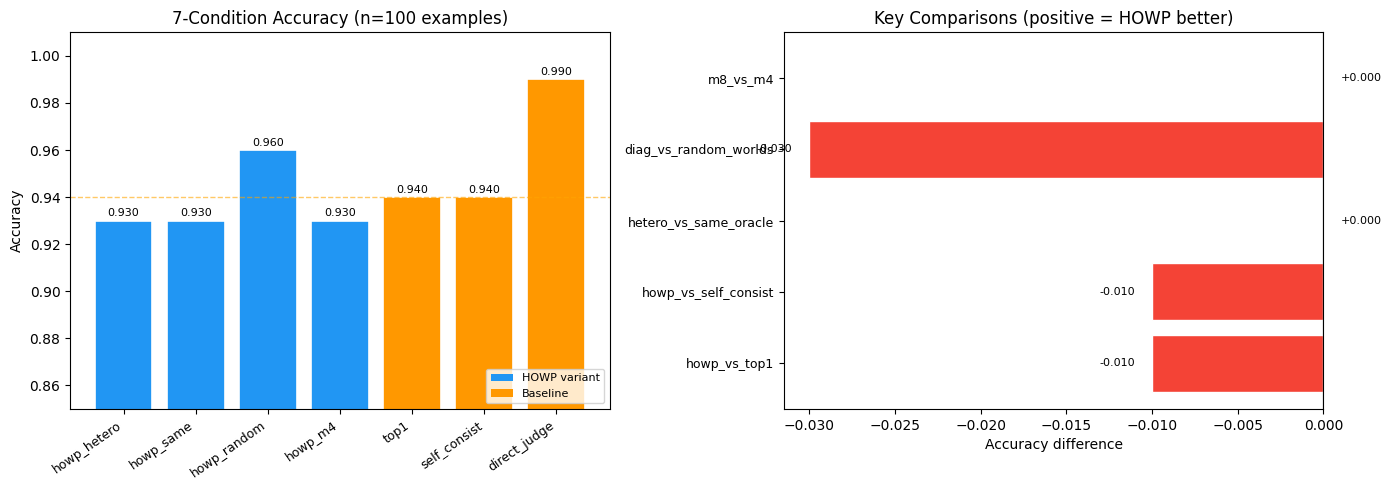


Key finding: With beam recall=100% and 70B generator, all methods perform similarly (0.93-0.99).
World-probing (HOWP) does NOT outperform simpler baselines on simple predicate-application sentences.
direct_judge (0.99) outperforms all HOWP variants — oracle judgment > world probing.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Condition accuracy bar chart ───────────────────────────────────────
cond_labels = CONDITIONS
accuracies = [main_results.get(c, {}).get('accuracy', 0) for c in cond_labels]
colors = ['#2196F3' if 'howp' in c else '#FF9800' for c in cond_labels]

ax1 = axes[0]
bars = ax1.bar(range(len(cond_labels)), accuracies, color=colors, edgecolor='white', linewidth=1.2)
ax1.set_xticks(range(len(cond_labels)))
ax1.set_xticklabels(cond_labels, rotation=35, ha='right', fontsize=9)
ax1.set_ylim(0.85, 1.01)
ax1.set_ylabel('Accuracy')
ax1.set_title('7-Condition Accuracy (n=100 examples)')
ax1.axhline(y=main_results.get('top1', {}).get('accuracy', 0), color='orange',
            linestyle='--', linewidth=1, alpha=0.6, label='top1 baseline')
ax1.legend(fontsize=8)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width() / 2, acc + 0.001, f'{acc:.3f}',
             ha='center', va='bottom', fontsize=8)

# Blue = HOWP variants, Orange = baselines
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='HOWP variant'),
                   Patch(facecolor='#FF9800', label='Baseline')]
ax1.legend(handles=legend_elements, fontsize=8, loc='lower right')

# ── Right: Key comparisons ────────────────────────────────────────────────────
ax2 = axes[1]
comp_keys = list(comparisons.keys())
comp_vals = list(comparisons.values())
bar_colors = ['#4CAF50' if v >= 0 else '#F44336' for v in comp_vals]
ax2.barh(range(len(comp_keys)), comp_vals, color=bar_colors, edgecolor='white')
ax2.set_yticks(range(len(comp_keys)))
ax2.set_yticklabels(comp_keys, fontsize=9)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_xlabel('Accuracy difference')
ax2.set_title('Key Comparisons (positive = HOWP better)')
for i, v in enumerate(comp_vals):
    ax2.text(v + 0.001 if v >= 0 else v - 0.001, i, f'{v:+.3f}',
             va='center', ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('results.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nKey finding: With beam recall=100% and 70B generator, all methods perform similarly (0.93-0.99).")
print("World-probing (HOWP) does NOT outperform simpler baselines on simple predicate-application sentences.")
print("direct_judge (0.99) outperforms all HOWP variants — oracle judgment > world probing.")